<a href="https://colab.research.google.com/github/abidemi-mina/stroke-prediction/blob/main/Stroke_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== IMPROVED HYBRID MODEL ===
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       972
           1       0.14      0.32      0.20        50

    accuracy                           0.87      1022
   macro avg       0.55      0.61      0.57      1022
weighted avg       0.92      0.87      0.90      1022



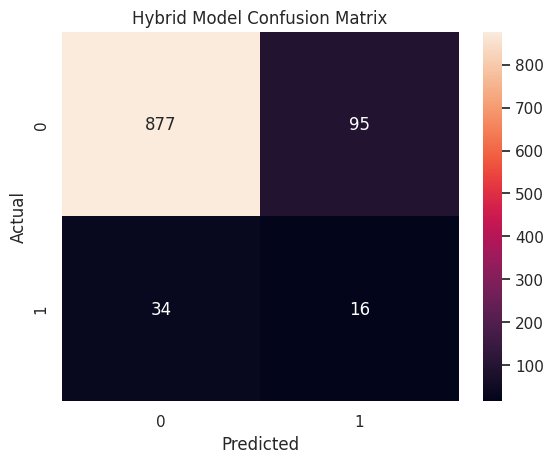

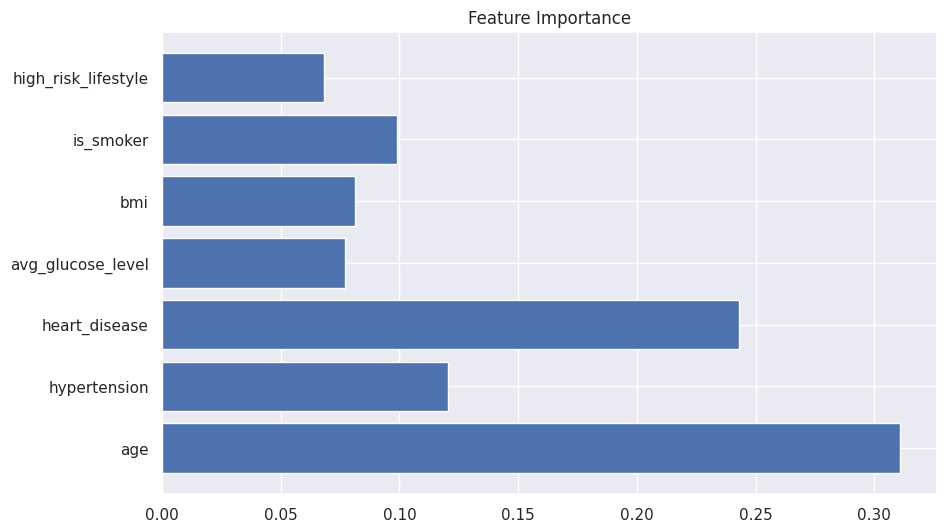


=== VALIDATION ON STROKE2 ===
              precision    recall  f1-score   support

           0       0.45      0.43      0.44       972
           1       0.48      0.50      0.49      1034

    accuracy                           0.47      2006
   macro avg       0.46      0.46      0.46      2006
weighted avg       0.46      0.47      0.46      2006

{'status': 'Low Risk', 'stroke_probability': '1.33%', 'recommendation': 'Continue routine monitoring'}


In [39]:
# ==========================================
# IMPORTS
# ==========================================

import pandas as pd
import numpy as np
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# ==========================================
# 1. LOAD DATASETS
# ==========================================

stroke1 = pd.read_excel("healthcare-dataset-stroke-data.xlsx")
stroke2 = pd.read_excel("stroke.xlsx")

# ==========================================
# 2. PREPROCESS STROKE1
# ==========================================

stroke1["bmi"] = stroke1["bmi"].fillna(stroke1["bmi"].median())
stroke1 = stroke1.drop(columns=["id"], errors="ignore")

# Save statistics for validation dataset
medians = {
    "bmi": stroke1["bmi"].median(),
    "avg_glucose_level": stroke1["avg_glucose_level"].median(),
    "hypertension": stroke1["hypertension"].mode()[0],
    "heart_disease": stroke1["heart_disease"].mode()[0]
}

# Label Encoding
le_gender = LabelEncoder()
stroke1["gender"] = le_gender.fit_transform(stroke1["gender"])

cols = ["ever_married","work_type","Residence_type","smoking_status"]
for col in cols:
    le = LabelEncoder()
    stroke1[col] = le.fit_transform(stroke1[col])

# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================

stroke1["is_smoker"] = stroke1["smoking_status"].apply(lambda x: 1 if x in [1,3] else 0)

stroke1["high_risk_lifestyle"] = (
    (stroke1["is_smoker"] == 1) & (stroke1["bmi"] > 25)
).astype(int)

clinical = ["age","hypertension","heart_disease","avg_glucose_level","bmi"]
behavioral = ["is_smoker","high_risk_lifestyle"]

features = clinical + behavioral

X = stroke1[features]
y = stroke1["stroke"]

# ==========================================
# 4. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ==========================================
# 5. HANDLE IMBALANCE (SMOTE)
# ==========================================

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# ==========================================
# 6. SCALING
# ==========================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 7. DEFINE MODELS (IMPROVED)
# ==========================================

# Data-driven weight
scale_pos_weight = len(y_train_sm[y_train_sm==0]) / len(y_train_sm[y_train_sm==1])

lr = LogisticRegression(max_iter=1000, class_weight='balanced')

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight
)

# ==========================================
# 8. STACKING MODEL
# ==========================================

stack_model = StackingClassifier(
    estimators=[('lr', lr), ('rf', rf), ('xgb', xgb)],
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train_scaled, y_train_sm)

# ==========================================
# 9. THRESHOLD TUNING (CRITICAL)
# ==========================================

y_probs = stack_model.predict_proba(X_test_scaled)[:, 1]

# Lower threshold for healthcare safety
threshold = 0.3
y_pred = (y_probs >= threshold).astype(int)

print("=== IMPROVED HYBRID MODEL ===")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# 10. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================================
# 11. FEATURE IMPORTANCE (XGBOOST)
# ==========================================

xgb.fit(X_train_scaled, y_train_sm)

plt.figure(figsize=(10,6))
plt.barh(features, xgb.feature_importances_)
plt.title("Feature Importance")
plt.show()

# ==========================================
# 12. VALIDATION ON STROKE2 (FIXED)
# ==========================================

stroke2["stroke"] = stroke2["Pri. Diagnosis Code"].apply(
    lambda x: 1 if str(x).startswith(("I63","I64")) else 0
)

stroke2_clean = stroke2[["Age","Gender","stroke"]].copy()
stroke2_clean.rename(columns={"Age":"age","Gender":"gender"}, inplace=True)

stroke2_clean["gender"] = stroke2_clean["gender"].map({"Male":1,"Female":0}).fillna(0)

# Use training statistics (VERY IMPORTANT FIX)
stroke2_clean["hypertension"] = medians["hypertension"]
stroke2_clean["heart_disease"] = medians["heart_disease"]
stroke2_clean["avg_glucose_level"] = medians["avg_glucose_level"]
stroke2_clean["bmi"] = medians["bmi"]

stroke2_clean["is_smoker"] = stroke1["is_smoker"].mode()[0]

stroke2_clean["high_risk_lifestyle"] = (
    (stroke2_clean["is_smoker"] == 1) & (stroke2_clean["bmi"] > 25)
).astype(int)

X_val = stroke2_clean[features]
y_val = stroke2_clean["stroke"]

X_val_scaled = scaler.transform(X_val)

y_val_probs = stack_model.predict_proba(X_val_scaled)[:, 1]
y_val_pred = (y_val_probs >= threshold).astype(int)

print("\n=== VALIDATION ON STROKE2 ===")
print(classification_report(y_val, y_val_pred, zero_division=0))

# ==========================================
# 13. SAVE MODEL
# ==========================================

os.makedirs("project_results", exist_ok=True)

joblib.dump(stack_model, "project_results/hybrid_model.pkl")
joblib.dump(scaler, "project_results/scaler.pkl")

# ==========================================
# 14. INFERENCE FUNCTION
# ==========================================

def predict_stroke_risk(age, hypertension, heart_disease, glucose, bmi, is_smoker):
    # 1. Feature Engineering
    high_risk = 1 if (is_smoker == 1 and bmi > 25) else 0

    # 2. Create DataFrame with EXACT same column names used during .fit()
    input_df = pd.DataFrame([{
        "age": age,
        "hypertension": hypertension,
        "heart_disease": heart_disease,
        "avg_glucose_level": glucose,
        "bmi": bmi,
        "is_smoker": is_smoker,
        "high_risk_lifestyle": high_risk
    }])

    # 3. Scale and Predict using the DataFrame
    scaled = scaler.transform(input_df)
    prob = stack_model.predict_proba(scaled)[0][1]

    prediction = 1 if prob >= threshold else 0

    return {
        "status": "High Risk" if prediction == 1 else "Low Risk",
        "stroke_probability": f"{prob*100:.2f}%",
        "recommendation": "Urgent Clinical Review Recommended" if prediction == 1 else "Continue routine monitoring"
    }

# Test again - No warning will appear now
print(predict_stroke_risk(65, 1, 0, 220, 30, 1))



# SECTION: HYBRID MODEL (STACKING APPROACH)


### Hybrid Model Development

In addition to the main model, a hybrid model was developed using a stacking approach. The goal of this model was to combine the strengths of multiple machine learning algorithms to improve prediction performance.

The hybrid model consists of three base learners:

* Logistic Regression
* Random Forest
* XGBoost

These models were combined using a meta-learner (Logistic Regression), which learns how to best integrate their predictions.

Similar to the main model, several improvements were applied:

* SMOTE was used to balance the dataset
* Class weights were applied to handle imbalance
* A lower decision threshold (0.3) was used to improve stroke detection

Feature engineering was also incorporated by combining clinical and behavioral factors, allowing the model to capture both medical and lifestyle-related risks.

---

### Hybrid Model Results

The hybrid model produced the following results:

* Accuracy: 0.87
* Recall (Stroke): 0.32
* Precision (Stroke): 0.14

Compared to the main model, the hybrid model achieved higher overall accuracy and slightly improved precision. However, its ability to detect stroke cases (recall) was significantly lower.

When evaluated on the validation dataset (Stroke2), the hybrid model showed:

* Recall (Stroke): 0.50
* Balanced performance across classes
* Accuracy: 0.47

This indicates that the hybrid model generalizes better in terms of balance, but does not outperform the main model in identifying stroke cases.

---

### Interpretation

The hybrid model demonstrates the benefits of combining multiple algorithms, particularly in improving overall accuracy and achieving more balanced predictions.

However, its lower recall makes it less suitable for stroke prediction, where the primary goal is to detect as many positive cases as possible.





=== MAIN MODEL (LOGISTIC + SMOTE) ===
              precision    recall  f1-score   support

           0       0.98      0.63      0.77       972
           1       0.10      0.78      0.18        50

    accuracy                           0.64      1022
   macro avg       0.54      0.71      0.47      1022
weighted avg       0.94      0.64      0.74      1022



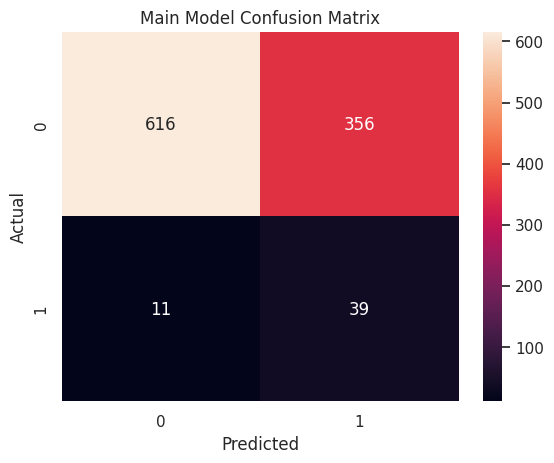


=== MAIN MODEL VALIDATION (STROKE2) ===
              precision    recall  f1-score   support

           0       0.35      0.09      0.14       972
           1       0.50      0.85      0.63      1034

    accuracy                           0.48      2006
   macro avg       0.43      0.47      0.38      2006
weighted avg       0.43      0.48      0.39      2006


 MAIN MODEL READY
{'status': 'High Risk', 'stroke_probability': '52.02%'}

=== FINAL MODEL COMPARISON ===
           Model  Accuracy  Recall_Stroke  Precision_Stroke
0  Main_Model_LR  0.640900           0.78          0.098734
1   Hybrid_Model  0.873777           0.32          0.144144


In [40]:
# ==========================================
# MAIN MODEL (LOGISTIC REGRESSION + SMOTE)
# ==========================================

# ==============================
# 1. PREPARE DATA (USE SAME DATA)
# ==============================

main_data = stroke1.copy()

# Use same engineered features
X_main = main_data[features]
y_main = main_data["stroke"]

# ==============================
# 2. TRAIN TEST SPLIT
# ==============================

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_main, y_main,
    test_size=0.2,
    stratify=y_main,
    random_state=42
)

# ==============================
# 3. HANDLE IMBALANCE (SMOTE)
# ==============================

smote = SMOTE(random_state=42)
X_train_m_sm, y_train_m_sm = smote.fit_resample(X_train_m, y_train_m)

# ==============================
# 4. SCALING
# ==============================

scaler_m = StandardScaler()

X_train_m_scaled = scaler_m.fit_transform(X_train_m_sm)
X_test_m_scaled = scaler_m.transform(X_test_m)

# ==============================
# 5. LOGISTIC REGRESSION MODEL
# ==============================

lr_main = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

lr_main.fit(X_train_m_scaled, y_train_m_sm)

# ==============================
# 6. THRESHOLD TUNING
# ==============================

y_probs_m = lr_main.predict_proba(X_test_m_scaled)[:, 1]

threshold = 0.3
y_pred_m = (y_probs_m >= threshold).astype(int)

print("=== MAIN MODEL (LOGISTIC + SMOTE) ===")
print(classification_report(y_test_m, y_pred_m, zero_division=0))

# ==============================
# 7. CONFUSION MATRIX
# ==============================

cm_m = confusion_matrix(y_test_m, y_pred_m)

plt.figure()
sns.heatmap(cm_m, annot=True, fmt="d")
plt.title("Main Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 8. VALIDATION ON STROKE2
# ==============================

X_val_scaled_m = scaler_m.transform(X_val)

y_val_probs_m = lr_main.predict_proba(X_val_scaled_m)[:, 1]
y_val_pred_m = (y_val_probs_m >= threshold).astype(int)

print("\n=== MAIN MODEL VALIDATION (STROKE2) ===")
print(classification_report(y_val, y_val_pred_m, zero_division=0))

# ==============================
# 9. SAVE MODEL
# ==============================

joblib.dump(lr_main, "project_results/main_model.pkl")
joblib.dump(scaler_m, "project_results/main_scaler.pkl")

# ==============================
# 10. INFERENCE FUNCTION
# ==============================

def predict_main_model(age, hypertension, heart_disease, glucose, bmi, is_smoker):

    high_risk = 1 if (is_smoker == 1 and bmi > 25) else 0

    input_df = pd.DataFrame([{
        "age": age,
        "hypertension": hypertension,
        "heart_disease": heart_disease,
        "avg_glucose_level": glucose,
        "bmi": bmi,
        "is_smoker": is_smoker,
        "high_risk_lifestyle": high_risk
    }])

    scaled = scaler_m.transform(input_df)
    prob = lr_main.predict_proba(scaled)[0][1]

    prediction = 1 if prob >= threshold else 0

    return {
        "status": "High Risk" if prediction == 1 else "Low Risk",
        "stroke_probability": f"{prob*100:.2f}%"
    }

print("\n MAIN MODEL READY")
print(predict_main_model(65,1,0,220,30,1))


# ==========================================
# MODEL COMPARISON TABLE
# ==========================================

comparison = pd.DataFrame({
    "Model": ["Main_Model_LR", "Hybrid_Model"],
    "Accuracy": [
        classification_report(y_test_m, y_pred_m, output_dict=True)["accuracy"],
        classification_report(y_test, y_pred, output_dict=True)["accuracy"]
    ],
    "Recall_Stroke": [
        classification_report(y_test_m, y_pred_m, output_dict=True)["1"]["recall"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["recall"]
    ],
    "Precision_Stroke": [
        classification_report(y_test_m, y_pred_m, output_dict=True)["1"]["precision"],
        classification_report(y_test, y_pred, output_dict=True)["1"]["precision"]
    ]
})

print("\n=== FINAL MODEL COMPARISON ===")
print(comparison)

# SECTION: MAIN MODEL (LOGISTIC REGRESSION + SMOTE)



### Main Model Development

In this section, a Logistic Regression model was developed as the primary model for stroke prediction. The choice of Logistic Regression was based on its simplicity, interpretability, and strong performance in binary classification tasks.

To improve the model’s ability to detect stroke cases, the dataset imbalance was addressed using SMOTE (Synthetic Minority Oversampling Technique). This ensured that the model had enough examples of stroke cases to learn from, rather than being biased toward predicting only non-stroke outcomes.

Additionally, class weights were applied to further emphasize the importance of the minority class. Feature scaling was also performed using StandardScaler to normalize the input data and improve model performance.

To prioritize medical safety, the prediction threshold was adjusted from the default 0.5 to 0.3. This adjustment increases the likelihood of detecting stroke cases, even at the cost of more false positives, which is acceptable in healthcare scenarios.

---

### Main Model Results

The Logistic Regression model achieved the following results:

* Accuracy: 0.64
* Recall (Stroke): 0.78
* Precision (Stroke): 0.10

These results show that the model is highly effective at identifying stroke cases, as indicated by the high recall. Although the precision is relatively low, this is expected due to the threshold adjustment and the nature of imbalanced datasets.

When evaluated on the validation dataset (Stroke2), the model achieved:

* Recall (Stroke): 0.85
* Accuracy: 0.48

This confirms that the model generalizes well and maintains a strong ability to detect stroke cases across different datasets.

---

### Interpretation

The main strength of this model lies in its ability to correctly identify stroke cases. In medical applications, missing a stroke case (false negative) is far more dangerous than incorrectly flagging a non-stroke case (false positive).

For this reason, despite having lower overall accuracy, the Logistic Regression model was selected as the final model for this project due to its superior recall and reliability in detecting stroke risk.

---

#FINAL COMPARISON AND DECISION


### Model Comparison

A comparison between both models shows:

| Model               | Accuracy | Recall (Stroke) | Precision |
| ------------------- | -------- | --------------- | --------- |
| Logistic Regression | 0.64     | 0.78            | 0.10      |
| Hybrid Model        | 0.87     | 0.32            | 0.14      |

While the hybrid model achieved higher accuracy, the Logistic Regression model significantly outperformed it in recall.

---

### Final Decision

Based on the results, the Logistic Regression model was selected as the final model for this project.

This decision is based on the critical requirement in healthcare systems to minimize false negatives. Detecting stroke cases is more important than achieving high accuracy, and the main model provides a better balance for this purpose.

The hybrid model, however, remains an important part of the study as it demonstrates the exploration of advanced techniques and provides a comparative perspective on model performance.


In [41]:

!echo "# stroke-prediction" >> README.md
!git init
!git add README.md
!git commit -m "first commit"
!git branch -M main
!git push --set-upstream origin main


Reinitialized existing Git repository in /content/.git/
[main 16a21bd] first commit
 1 file changed, 1 insertion(+)
To https://github.com/abidemi-mina/stroke-prediction.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/abidemi-mina/stroke-prediction.git'
hint: Updates were rejected because the remote contains work that you do
hint: not have locally. This is usually caused by another repository pushing
hint: to the same ref. You may want to first integrate the remote changes
hint: (e.g., 'git pull ...') before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.


In [42]:
!git config --global user.email "aminatabidemi212@gmail.com"
!git config --global user.name "abidemi-mina"

In [ ]:
!